### Importing Libraries

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
import pandas as pd, numpy as np, matplotlib.pyplot as plt

### Load Dataset

In [9]:
data = pd.read_csv("../Data Set/credit_risk_dataset.csv")

### Data Cleaning

In [10]:
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
print(data.isnull().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [11]:
data["person_emp_length"].dtype
data['person_emp_length'] =data['person_emp_length'].fillna(data['person_emp_length'].mean())
data.fillna({'person_emp_length': data['person_emp_length'].mean()}, inplace=True)

In [12]:
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
data['loan_int_rate'] =data['loan_int_rate'].fillna(data['loan_int_rate'].mean())
data.fillna({'loan_int_rate': data['loan_int_rate'].mean()}, inplace=True)

In [ ]:
print(data.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [14]:
data.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

### EDA

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

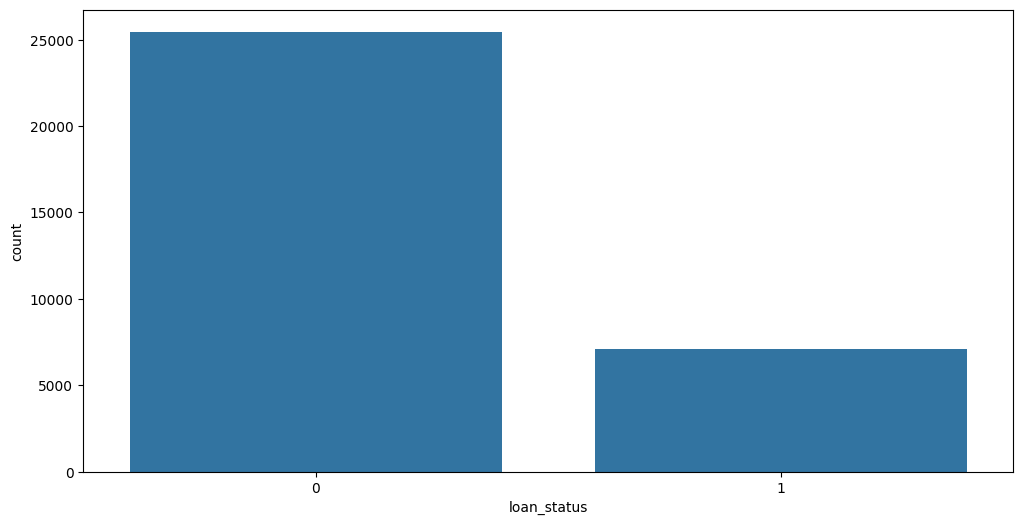

In [16]:
plt.figure(figsize=(12,6))
sns.countplot(x='loan_status',data=data)
plt.show()

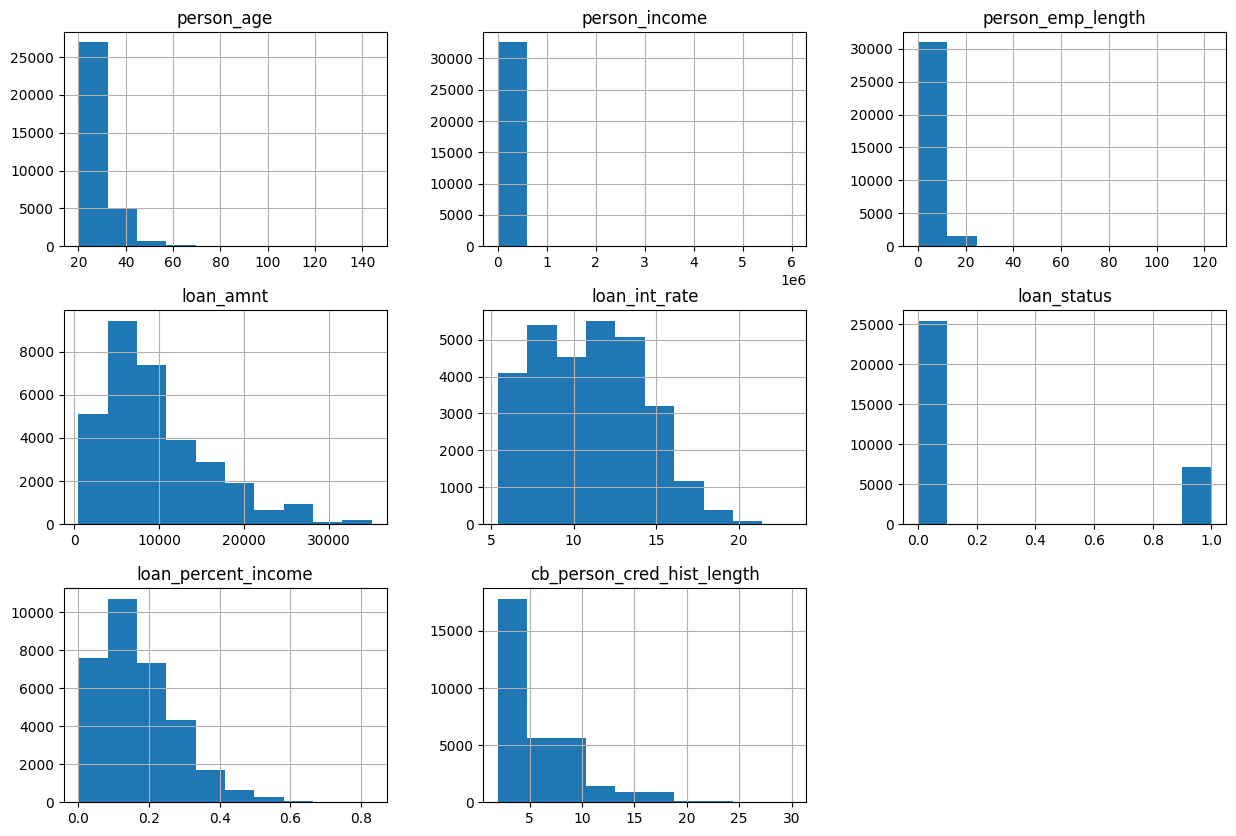

In [17]:
data.hist(figsize=(15,10))
plt.show()

In [21]:
data.skew(numeric_only=True)

person_age                     2.581393
person_income                 32.865349
person_emp_length              2.651118
loan_amnt                      1.192477
loan_int_rate                  0.208550
loan_status                    1.364888
loan_percent_income            1.064669
cb_person_cred_hist_length     1.661790
dtype: float64

### Encoding

In [ ]:
encoders = {}
categorial_columns = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
for column in categorial_columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    encoders[column] = le

### Feature Selection

In [ ]:
X = data.drop('loan_status',axis=1)
Y = data['loan_status']

In [11]:
X_train, X_test, y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

### Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Decision Tree Algorithm

In [ ]:
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

### Accuracy Score

In [17]:
print("train accuracy",accuracy_score(y_train,train_pred))
print("test accuracy",accuracy_score(Y_test,test_pred))

train accuracy 1.0
test accuracy 0.8856835967469695


### Classification Report

In [18]:
print(classification_report(y_train, train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20401
           1       1.00      1.00      1.00      5663

    accuracy                           1.00     26064
   macro avg       1.00      1.00      1.00     26064
weighted avg       1.00      1.00      1.00     26064



In [19]:
print(encoders['person_home_ownership'].classes_)

['MORTGAGE' 'OTHER' 'OWN' 'RENT']


### Dumping Pickle Files

In [20]:
import pickle

In [21]:
pickle.dump(model,open('model.pkl','wb'))
pickle.dump(encoders,open('encoders.pkl','wb'))

In [ ]:
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,3,123.0,4,3,35000,16.02,1,0.59,1,3
1,21,9600,2,5.0,1,1,1000,11.14,0,0.10,0,2
2,25,9600,0,1.0,3,2,5500,12.87,1,0.57,0,3
3,23,65500,3,4.0,3,2,35000,15.23,1,0.53,0,2
4,24,54400,3,8.0,3,2,35000,14.27,1,0.55,1,4


In [23]:
with open ("scaler.pkl","wb") as file:
  pickle.dump(scaler,file)